# Homework 5
## Radiative Transfer in a Forest Canopy
This homework will follow the multi-layer canopy model of Norman (1979) 

_Norman, J. M. 1979: Modeling the complete crop canopy. in: <u> Modification of the Aerial Environment of Plants</u>, ed.: B. J. Barfield & J. F. Gerber. American Socienty of Agricultural Engineers, pp. 249-277._

In [1]:
from datetime import datetime

import sys
import matplotlib.pyplot as plt
from matplotlib import cm

import numpy as np 

from scipy.linalg import solve_banded

# Here we will be using the MetPy library, which allows us to do some very meteorological things with the data
from metpy.plots import SkewT
from metpy.units import units
import metpy.calc as calc
import metpy.constants as c

import warnings
warnings.filterwarnings('once', category=UserWarning)

For two-stream radiative transfer in a canopy with $N$ layers, there are $2(N+1)$ equations to solve. The function `canopy_rad_sw` below sets up a tri-diagonal matrix to solve the equations. <u>This is a very common approach to solving single-column sets of predictive equations</u>, and there are accurate and efficient numerical methods to solve tridiagonal matrices. Here, we use the SciPy routine `solve_banded` from the linear algebra `linalg` package.

Also below is a function to generate some nice plots of the results, called `canopy_rad_sw_plot`.

In [4]:
def canopy_rad_sw (toc_diffuse,toc_direct,sol_zenith,n_layers,lai,    
                   trans_leaf,refl_leaf,albedo_sfc_diffuse=0.2,albedo_sfc_direct=0.2):

    """
    Given incoming direct and diffuse radiation, ground surface albedos and characteristics of the vegetation 
        canopy, calculate radiative transfer through the canopy, accounting for absorption, transmission and 
        multiple reflections.  
        
    Follows the Norman (1979) multi-layer canopy model as described in Bonan (2019)
    
    Can be called separately for different bands, making sure the inputs are appropriate for each band.
    
    Required inputs:
        toc_diffuse        (float) = Top of the canopy incoming diffuse shortwave radiation [W/m**2]
        toc_direct         (float) = Top of the canopy incoming direct shortwave radiation [W/m**2]
        sol_zenith         (float) = Solar zenith angle [degrees] 
        n_layers             (int) = Number of canopy layers
        lai                (array) = Canopy layer fraction blocked shortwave radiation (effective layer LAI) [0-1]
        trans_leaf         (array) = Canopy layer leaf transmissivity for shortwave radiation [0-1]
        refl_leaf          (array) = Canopy layer leaf reflectivity for shortwave radiation [0-1]        
        
    Optional inputs:
        albedo_sfc_diffuse (float) = Surface (soil) albedo for diffuse shortwave radiation [0-1]
        albedo_sfc_direct  (float) = Surface (soil) albedo for direct shortwave radiation [0-1]
        
    Outputs:
        Transmitted radiation (first array element is between lowest canopy layer and ground;
                                    last array element is immediately above top canopy layer):
            diffuse_up     (array) = Upward diffuse radiation between each layer (n_layers+1 values) [W/m**2]
            diffuse_down   (array) = Downward diffuse radiation between each layer (n_layers+1 values) [W/m**2]
            direct_down    (array) = Downward direct radiation between each layer (n_layers+1 values) [W/m**2]
        Absorbed radiation in canopy (first array element is absorption by lowest canopy layer;
                                          last array element is absorption by top canopy layer):
            canopy_diffuse (array) = Diffuse radiation absorbed by each canopy layer (n_layers values) [W/m**2]
            canopy_direct  (array) = Direct radiation absorbed by each canopy layer (n_layers values) [W/m**2]
        Absorbed radiation at ground:
            ground_diffuse (float) = Diffuse radiation absorbed by ground [W/m**2]
            ground_direct  (float) = Direct radiation absorbed by ground [W/m**2]
        
    """
    # Increased extinction if solar zenith angle > 0
    mu = 1.0 / np.cos(np.pi*sol_zenith/180)   # This follows from class notes
    
    # Find fraction of direct radiation that should penetrate each canopy layer
    unblocked_diffuse = np.exp(-lai)
    unblocked_direct = np.exp(-lai*mu)        # Note this has a direction µ because it is direct beam radiation
    unblocked_accum = np.full(n_layers+1,1.0) # Make a filled array first
    for i in range(n_layers-1,-1,-1):         # Then calculate the fraction of radiation getting to each layer
        unblocked_accum[i] = np.prod(unblocked_direct[i:n_layers])
        
    # Find terms for tri-diagonal matrix solution of the Norman (1979) multi-layer canopy model
    # As described in Bonan (2019; "Climate Change and Terrestrial Ecosystem Modeling")
    a = (1-unblocked_diffuse)*refl_leaf - (unblocked_diffuse + (1-unblocked_diffuse)*trans_leaf)**2 / ((1-unblocked_diffuse)*refl_leaf)
    b = (unblocked_diffuse + (1-unblocked_diffuse)*trans_leaf) / ((1-unblocked_diffuse)*refl_leaf)
    c = np.append(albedo_sfc_direct*toc_direct*unblocked_accum[0] , toc_direct*unblocked_accum[1:]*(1-unblocked_direct)*(refl_leaf - trans_leaf*b))
    d = np.append(toc_direct*unblocked_accum[1:]*(1-unblocked_direct)*(trans_leaf-refl_leaf*b) , toc_diffuse)

    # Lower diagonal, upper diagonal and diagonal
    ld = -np.append(np.stack((a, b)).T.flatten(),[0.0]*2,axis=0)
    ud = -np.append([0.0,albedo_sfc_diffuse],np.stack((b, a)).T.flatten(),axis=0)
    dd = np.array([1.0]*2*(n_layers+1))
    vv = np.stack((c, d)).T.flatten()
    
    nu_rad = solve_banded((1,1),np.array([ud,dd,ld]),vv)  # Solve tri-diagonal matrix
    nu_rad = nu_rad.reshape((n_layers+1,2))               # Separate upward terms from downward 
    diffuse_up = nu_rad[:,0]
    diffuse_down = nu_rad[:,1]
    direct_down = unblocked_accum*toc_direct              # Direct is only downward - reflected becomes diffuse
    
    # Calculate the absorbed amounts by each canopy level, and the ground
    canopy_diffuse = (diffuse_down[1:] + diffuse_up[:-1]) * (1-unblocked_diffuse) * (1-trans_leaf-refl_leaf)
    canopy_direct  = toc_direct*unblocked_accum[1:] * (1-unblocked_direct) * (1-trans_leaf-refl_leaf)
    ground_diffuse = diffuse_down[0] * (1-albedo_sfc_diffuse)
    ground_direct  = toc_direct*unblocked_accum[0] * (1-albedo_sfc_direct)
        
    return diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct

#-------------------------------------------------------------------------------------------------------

def canopy_rad_sw_plot(dlai,diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct):

    """
    Produces a plot of the vertical profile of shortwave radiation in the canopy
    
    Inputs:
        Transmitted radiation (first array element is between lowest canopy layer and ground;
                                    last array element is immediately above top canopy layer):
            diffuse_up     (array) = Upward diffuse radiation between each layer (n_layers+1 values) [W/m**2]
            diffuse_down   (array) = Downward diffuse radiation between each layer (n_layers+1 values) [W/m**2]
            direct_down    (array) = Downward direct radiation between each layer (n_layers+1 values) [W/m**2]
        Absorbed radiation in canopy (first array element is absorption by lowest canopy layer;
                                          last array element is absorption by top canopy layer):
            canopy_diffuse (array) = Diffuse radiation absorbed by each canopy layer (n_layers values) [W/m**2]
            canopy_direct  (array) = Direct radiation absorbed by each canopy layer (n_layers values) [W/m**2]
        Absorbed radiation at ground:
            ground_diffuse (float) = Diffuse radiation absorbed by ground [W/m**2]
            ground_direct  (float) = Direct radiation absorbed by ground [W/m**2]
        
    """
    
    n_layers = len(canopy_diffuse)                  # Figure out how many layers from size of arrays
    incoming = (direct_down[-1] + diffuse_down[-1]) # Total incoming solar radiation (direct + diffuse)
    net_albedo = diffuse_up[-1] / incoming          # Net albedo 
    absorbed = incoming * (1-net_albedo)            # What isn't reflected (diffuse up at top) is absorbed
    
    ##################################
    # Canopy radiation plot - 2 panels
    fig, (ax0,ax1) = plt.subplots(2,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[4,1]})
    plt.subplots_adjust(wspace=0.0,hspace=0.10,left=0.03,right=0.97,bottom=0.07,top=0.95)  

    # Top panel is a cross-section vertically through the canopy
    # Downwelling radiation
    ax0.plot(direct_down[-1],n_layers+0.5,c='orange',marker='v',ms=20)      # Highlight value above canopy
    ax0.plot(direct_down,np.arange(n_layers+1)+0.5,c='orange',marker='v',ms=10,label="Downward Direct")
    ax0.plot(diffuse_down[-1],n_layers+0.5,c='skyblue',marker='P',ms=18)    # Highlight value above canopy
    ax0.plot(diffuse_down,np.arange(n_layers+1)+0.5,c='skyblue',marker='P',ms=10,label="Downward Diffuse")
    # Upwelling radiation
    ax0.plot(diffuse_up[-1],n_layers+0.5,c='darkseagreen',marker='^',ms=20) # Highlight value above canopy
    ax0.plot(diffuse_up,np.arange(n_layers+1)+0.5,c='darkseagreen',marker='^',ms=10,label="Upward Diffuse")
    # Absorbed by each canopy layer
    ax0.plot(canopy_direct,np.arange(n_layers)+1,ls='',c='tab:red',marker='o',ms=10,label="Absorbed Direct")
    ax0.plot(canopy_diffuse,np.arange(n_layers)+1,ls='',c='tab:purple',marker='X',ms=10,label="Absorbed Diffuse")
    # Labels and legend
    ax0.set_ylabel("Canopy Layer LAI\n",fontsize=20)
    ax0.tick_params('y',labelsize=16)
    ax0.grid(visible=True)
    ax0.legend(fontsize=18,loc='lower right')
    # Add in canopy attributes
    ax0.set_yticks(np.arange(n_layers)+1,dlai) # Label each layer with its LAI
    for i in range(n_layers):  # Also label values of reflectivity and transmissivity
        ax0.text(0,i+1,f"r={refl_leaf[i]:.3} \n",ha='right',va='bottom',c='dimgrey',fontsize=11)
        ax0.text(0,i+1,f"\nt={trans_leaf[i]:.3} ",ha='right',va='top',c='dimgrey',fontsize=11)
    ax0.set_title(f"Net Surface Albedo (Canopy and Ground) = {net_albedo:.3f}",fontsize=20)
    ax0.text(np.max([diffuse_down[-1],direct_down[-1]])*1.04,(n_layers+1)*0.35,"Radiation in the Canopy",fontsize=20,ha='right',va='bottom',fontweight='bold')

    # Plot absorbed radiation
    bars = np.array([ground_diffuse,ground_direct,canopy_diffuse.sum(),canopy_direct.sum()])
    colors = ['peru','saddlebrown','limegreen','forestgreen']
    ax1.grid(visible=True,axis='x')
    ax1.barh(np.arange(4),bars,height=0.8,color=colors,label="Absorbed")
    for i in range(4):
        if bars[i]*5 < np.max([diffuse_down[-1],direct_down[-1]]):
            ax1.text(bars[i],i,f"  {bars[i]:.1f} $W/m^2$",c='k',va='center',ha='left',fontsize=16)
        else:
            ax1.text(bars[i],i,f"{bars[i]:.1f} $W/m^2$  ",c='w',va='center',ha='right',fontsize=16)
    ax1.set_xlabel("Radiative flux [$W/m^2$]",fontsize=20)
    ax1.set_yticks(np.arange(4),labels=["Ground Diffuse","Ground Direct","Canopy Diffuse","Canopy Direct"],fontsize=16)
    ax1.tick_params('x',labelsize=16)
    ax1.text(np.max([diffuse_down[-1],direct_down[-1]])*1.04,0.5,"Absorbed Radiation",fontsize=20,ha='right',va='center',fontweight='bold')
    ax1.set_title(f"Incoming Shortwave Radiation = {incoming:.1f} $W/m^2$, Total Absorbed = {absorbed:.1f} $W/m^2$",fontsize=20)

    plt.show()
    return

----------------------
## Part A. Running the model:

The cell below sets the parameters for the model, calls it to determine the distribution of radiation in the canopy, and then calls a function to plot the results.

To start, we have the following parameters:
* Radiation parameters:
    * Incoming shortwave radiation at the top of the canopy = 500 $W/m^2$
    * Evenly split between direct and diffuse
    * Sun angle is directly overhead; solar zenith angle = 0˚
* Vegetation parameters:
    * Total leaf area index of canopy = 1 ; leaves equally and randomly distributed in each layer
    * Number of canopy layers = 5 
    * Transmissivity and reflectivity of each leaf both equal 0.1 ; so 80% of radiation is absorbed 
* Ground surface parameters:
    * The ground has a "white sky" albedo (i.e., for diffuse radiation) of 0.2
    * It also has a "black sky" albedo (i.e., for direct radiation) of 0.2

See how these parameters are specified in the cell below, then run it to see what happens.

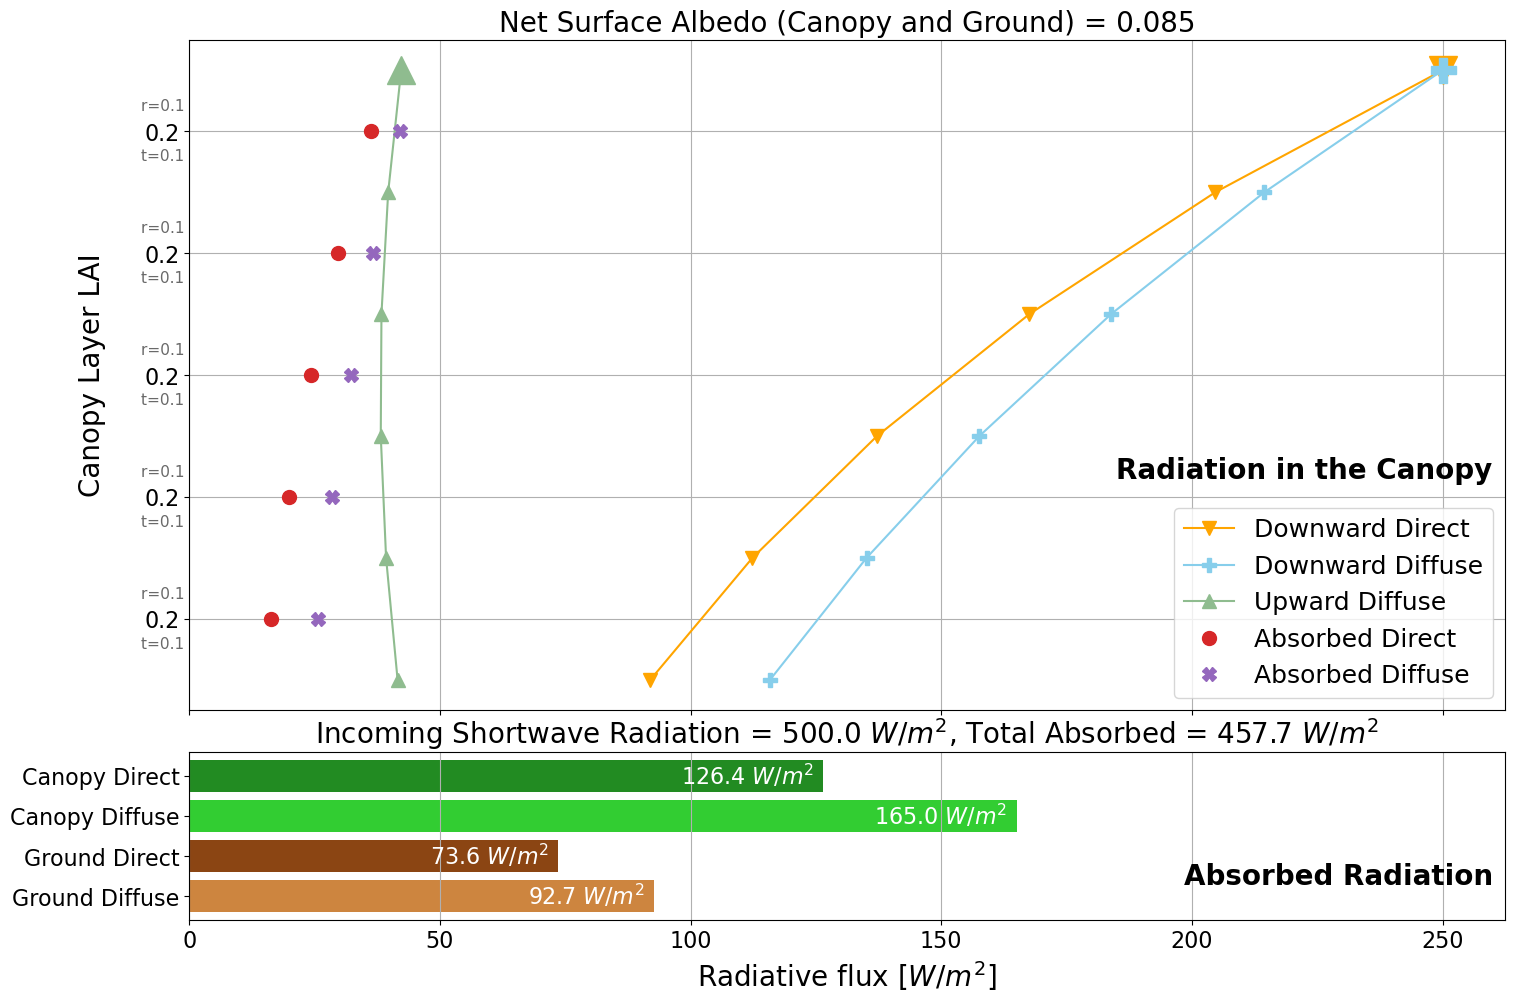

In [5]:
########################################################################################
# Radiation parameters
total_sw_rad = 500    # [W/m^2]
frac_direct  = 0.5    # Fraction that is direct radiation [0:1]
sol_zenith  = 0       # Solar zenith angle [0:90 degrees]

# Vegetation parameters
lai                = 1 
n_layers           = 5                        # Number of canopy layers
dlai               = np.array([lai/n_layers]*n_layers) # Effective LAI of each layer [0:1]
trans_leaf         = np.array([0.1]*n_layers)  # Transmissivity of leaves in each layer [0:1]
refl_leaf          = np.array([0.1]*n_layers)  # Reflectivity of leaves in each layer [0:trans_leaf]
                                               # Absorptivity of leaves = 1-trans_leaf-refl_leaf ≥ 0
# Ground surface parameters
albedo_sfc_diffuse = 0.2                       # "White sky" albedo of the ground [0:1]
albedo_sfc_direct  = 0.2                       # "Black sky" albedo of ground [0:1]
########################################################################################

# Call to the function that calculates canopy radiative transfer
diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct \
                                               = canopy_rad_sw(total_sw_rad*(1-frac_direct),total_sw_rad*frac_direct,
                                                               sol_zenith,n_layers,dlai,trans_leaf,refl_leaf,
                                                               albedo_sfc_diffuse,albedo_sfc_direct)
# Create the plot
fig = canopy_rad_sw_plot(dlai,diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct)

The X-axis is the flux of radiation. In the upper panel, the Y-axis is a vertical dimension through the canopy.

The grid lines represent the discrete canopy layers - think of them as where the leaves are. The LAI of each layer is plotted on the left, along with the reflectivity (r) and transmissivity (t). The curves show the vertical profiles of radiation moving down (orange and blue) and up (green) through the canopy. The marks on the layer lines show the total amont of radiation absorbed by the leaves in that layer (among the simplifications in this model, we are ignoring stems and trunks).

The bottom panel is a bar chart of the toal absorbed radiation by canopy (green) and ground (brown), divided into direct and diffuse radiation.

Also shown at the top of the plot is the calculated net albedo (a feature of this model is that it calculates the effective surface albedo as it would be measured looking down from the sky above the ground), and between the panels the total absorbed radiation.

### Answer some questions

1. As we go down into the canopy from above, the downward direct radiation depletes faster than the diffuse. Why do you think this is so?
2. The upward diffuse radiation is minimum around the middle of the canopy, larger both near the ground and near the top. Why do you think this is so?
3. Add up the diffuse radiation absorbed by canopy and ground. Compare it to the incoming diffuse radiation. How could more diffuse radiation be absorbed than the incoming diffuse radiation at the top of the canopy?

----------------------
## Part B. White sky and black sky 

A white sky means all diffuse radiation. This can happen under overcast conditions - 100% clound cover. Black sky cannot occur on Earth's surface because even a pristine cloud-free atmosphere scatters some light (why it appears blue). But it is still instructive to run our model for each and see what happens. 
* For black sky, set `frac_direct = 1.0`
* For white sky, set `frac_direct = 0.0`

Copy the code cell from Part A below and try each of these cases.

### Answer some questions

1. Black sky (like there was a forest on the surface of the moon) gives a clear picture of just how much direct solar radiation gets scattered into diffuse radiation by reflection and transmission. What fraction of the total absorbed radiation is diffuse?
2. White sky - notice how different the profile looks compared to black sky. Describe what is different and what is nearly (or exactly) the same.

----------------------
## Part C. Sun angle

Set your model for a clear "blue sky" scenario of `frac_direct = 0.8`. Then try two different sun angles:
* Overhead sun: `sol_zenith = 0`
* Sun low in the sky: `sol_zenith = 75`
Again, copy code cells below to run these cases.

### Answer some questions

1. Now things look quite different! Describe what has changed with the vertical profiles of direct radiation, and explain why they have changed.
2. Notice the amount of light that is reaching the surface. What has happened when the sun is low in the sky? Have you ever been in a forest around sunset - is this consistent with your experience?

----------------------
## Part D. Snow on the ground

Let's keep `sol_zenith = 75` and simulate snow on the ground. Change the two ground surface albedos from 0.2 to 0.9 and rerun.

### Answer some questions

1. Compare to the "snow free" case with the same solar zenith angle. The direct radiation in the canopy is unaffected, but now we see very different profiles for diffuse radiation, and the light absorbed at the ground. Describe what has happened and why.
2. This is like a pine forest in winter with snow on the ground. Is the canopy absorbing more or less energy than the snow-free situation? Is snow cover beneficial for photosynthesis, and why?
3. What is the net albedo when there is snow cover? How does it compare to snow-free? 

    a. Decrease the solar zenith angle to 30˚ and check again. 
    
    b. Then increase the LAI to 3 and check again. 
    
    What can you say about the sensitivity of albedo, and the canopy radiation budget to sun angle and the LAI (density of leaves in the canopy) when the ground is highly reflective?

----------------------
## Part E. Canopy density

We just got a taste of what happens when LAI increases, representing a denser canopy of leaves. Let's use the parameters below as a starting point. We've set the ground albedo to 0.3 (like a sandy soil) and zenith angle to 30˚. 

Try running the code for a range of LAIs from 0 to 5 at intervals of 0.5 and make a table in your answer block below of the corresponding net surface albedos.  **Note:** the code will crash if you set `lai = 0` so instead set it to a very small number like `lai = 0.001` (this is actually a _bug/feature_ of many LSMs: even in the middle of the Sahara they will set a very small positive LAI so the radiation subroutine doesn't crash).

In [ ]:
########################################################################################
# Radiation parameters
total_sw_rad = 500    # [W/m^2]
frac_direct  = 0.8    # Fraction that is direct radiation [0:1]
sol_zenith   = 30     # Solar zenith angle [0:90 degrees]

# Vegetation parameters
lai                = 1 
n_layers           = 5                        # Number of canopy layers
dlai               = np.array([lai/n_layers]*n_layers) # Effective LAI of each layer [0:1]
trans_leaf         = np.array([0.1]*n_layers)  # Transmissivity of leaves in each layer [0:1]
refl_leaf          = np.array([0.1]*n_layers)  # Reflectivity of leaves in each layer [0:trans_leaf]
                                               # Absorptivity of leaves = 1-trans_leaf-refl_leaf ≥ 0
# Ground surface parameters
albedo_sfc_diffuse = 0.3                       # "White sky" albedo of the ground [0:1]
albedo_sfc_direct  = 0.3                       # "Black sky" albedo of ground [0:1]
########################################################################################

# Call to the function that calculates canopy radiative transfer
diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct \
                                               = canopy_rad_sw(total_sw_rad*(1-frac_direct),total_sw_rad*frac_direct,
                                                               sol_zenith,n_layers,dlai,trans_leaf,refl_leaf,
                                                               albedo_sfc_diffuse,albedo_sfc_direct)
# Create the plot
fig = canopy_rad_sw_plot(dlai,diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct)

### Put your table below, then answer a question:

The albedo decreases as LAI increases... until it doesn't. How could the minimum reflection of light from this canopy be at an intermediate level of LAI, and that value is lower than either the canopy reflectivity or the ground reflectivity (albedo)? What is going on? (Hint: It's not a mistake - this is realistic.)

----------------------
## Part F. Near-infrared parameters

Did you notice that the parameters we have been using so far are for visible light, and not for shortwave radiation as a whole? The amount of visible and near-infrared radiation reaching the top of the canopy from above is roughly equal. But in the absence of clouds, more of the near-IR is direct radiation, and the canopy parameters are quite different. The code block below is for NIR settings.

In [ ]:
########################################################################################
# Radiation parameters
total_sw_rad = 500    # [W/m^2]
frac_direct  = 0.9    # Fraction that is direct radiation [0:1]
sol_zenith   = 30     # Solar zenith angle [0:90 degrees]

# Vegetation parameters
lai                = 1
n_layers           = 5                        # Number of canopy layers
dlai               = np.array([lai/n_layers]*n_layers) # Effective LAI of each layer [0:1]
trans_leaf         = np.array([0.4]*n_layers)  # Transmissivity of leaves in each layer [0:1]
refl_leaf          = np.array([0.5]*n_layers)  # Reflectivity of leaves in each layer [0:trans_leaf]
                                               # Absorptivity of leaves = 1-trans_leaf-refl_leaf ≥ 0
# Ground surface parameters
albedo_sfc_diffuse = 0.3                       # "White sky" albedo of the ground [0:1]
albedo_sfc_direct  = 0.3                       # "Black sky" albedo of ground [0:1]
########################################################################################

# Call to the function that calculates canopy radiative transfer
diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct \
                                               = canopy_rad_sw(total_sw_rad*(1-frac_direct),total_sw_rad*frac_direct,
                                                               sol_zenith,n_layers,dlai,trans_leaf,refl_leaf,
                                                               albedo_sfc_diffuse,albedo_sfc_direct)
# Create the plot
fig = canopy_rad_sw_plot(dlai,diffuse_up,diffuse_down,direct_down,canopy_diffuse,canopy_direct,ground_diffuse,ground_direct)

Yikes! This looks completely different! Not only are leaves highly reflective in near-IR (albedo of 0.5 in our settings) but they are also quite transparent, transmitting 40% of near-IR light through the leaves, only absorbing 10%. In the near-IR part of the spectrum, leaves look like frosted glass. Those [infrared photographs of trees looking like they are flocked with (fake) snow](https://www.google.com/search?q=infrared+photo+trees) make sense now! 

### Answer some questions

1. Compare to the `lai = 1` case from Part E - what has changed about the vertical profiles of diffuse radiation in the canopy, and absorption of radiation?

2. What has changed about the surface radiation?

----------------------
## Part G. Be curious

Try some crazy settings - you can't break anything. The worst that can happen is the model crashes. Tell what you tried and discuss what you see. 
